In [17]:
import pandas as pd
import numpy as np
from uncertainties import unumpy as unp
from uncertainties import ufloat
from uncertainties.unumpy import log as ulog
import warnings
warnings.filterwarnings('ignore')
from cluster_functions import *

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import FormatStrFormatter
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import ticker

labelsize=12
palette = 'viridis'
font = { 'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}


In [3]:
data = pd.read_csv('Dados\data.csv', index_col='Cluster')
df = pd.read_csv(r'Dados\results.csv', index_col='Cluster')

In [6]:
for cluster in df.index:
    data.loc[cluster, 'r/rh'], df.loc[cluster, 'rh']  = half_mass_ratio(data.loc[cluster], df.loc[cluster]['dist'])

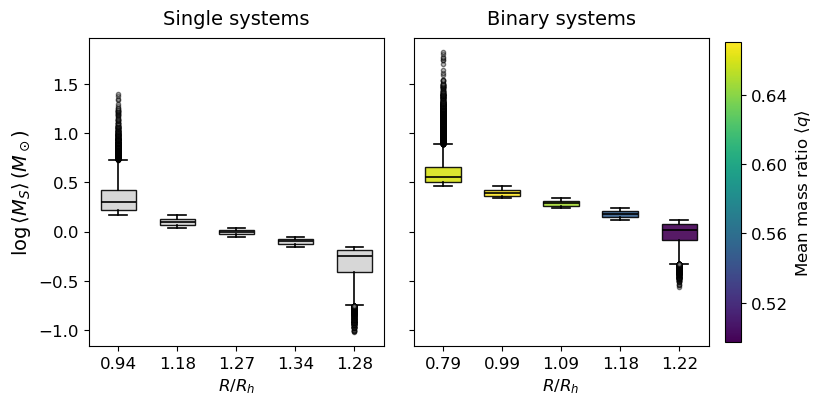

In [27]:
data['mass_system'] = data['mass'] + data['comp_mass']

binarias = data[data.q>0]
binarias =  binarias.sort_values(by='mass_system').reset_index(drop=True)

singles = data[data.q==0]
singles = singles.sort_values(by='mass_system').reset_index(drop=True)

n_div = 5

subconjuntos_singles = np.array_split(singles, n_div)
subconjuntos_binarias = np.array_split(binarias, n_div)

# Dados para o boxplot
box_mass_bin = []       # valores de r/rh por bin
box_q = []         # razão de massa média por bin
box_labels_bin = []    # rótulos de massa média por bin

box_mass_sig = []
box_labels_sig = []

for i in range(n_div):
    rrh_mean = subconjuntos_binarias[i]['r/rh'].median()
    q_mean = subconjuntos_binarias[i]['q'].mean()
    m_vals = subconjuntos_binarias[i]['mass_system'].values

    box_mass_bin.append(np.log10(m_vals))
    box_q.append(q_mean)
    box_labels_bin.append(f'{rrh_mean:.2f}')

    rrh_mean = subconjuntos_singles[i]['r/rh'].median()

    m_vals = subconjuntos_singles[i]['mass_system'].values

    box_mass_sig.append(np.log10(m_vals))
    box_labels_sig.append(f'{rrh_mean:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True, gridspec_kw={'hspace': 0.2, 'wspace': 0.1})

# ==========================
# Colormap
# ==========================
norm = mcolors.Normalize(vmin=np.min(box_q), vmax=np.max(box_q))
cmap = cm.viridis


def styled_boxplot(ax, data, box_labels, title, color_by_q=True):

    bp = ax.boxplot(
        data,
        patch_artist=True,
        widths=0.6,
        showfliers=True,
        flierprops=dict(
            marker='o',
            markersize=3,
            markerfacecolor='gray',
            markeredgecolor='black',
            alpha=0.5
        )
    )

    # Colorir boxes
    for i, patch in enumerate(bp['boxes']):
        if color_by_q:
            patch.set_facecolor(cmap(norm(box_q[i])))
        else:
            patch.set_facecolor('lightgray')
        patch.set_edgecolor('black')
        patch.set_alpha(0.9)

    # Estilo linhas
    for element in ['whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color('black')
            item.set_linewidth(1.2)

    # Eixos
    ax.set_xticklabels(box_labels, fontsize=12)
    ax.set_xlabel(r'$R / R_h$', fontsize=12)
    ax.set_title(title, fontsize=14, pad=10)

    ax.tick_params(axis='y', labelsize=12)
    ax.invert_xaxis()

    return bp


# ==========================
# Painéis
# ==========================
styled_boxplot(
    ax[1],
    box_mass_bin,
    box_labels_bin,
    title='Binary systems'
)

styled_boxplot(
    ax[0],
    box_mass_sig,
    box_labels_sig,
    title='Single systems',
    color_by_q=False
)

# ==========================
# Eixo Y
# ==========================
ax[0].set_ylabel(
    r'$\log\langle M_S \rangle\,(M_\odot)$',
    fontsize=14
)

# ==========================
# Colorbar
# ==========================


cax = fig.add_axes([0.92, 0.12, 0.02, 0.75])  # [left, bottom, width, height] em fração da figura
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r'Mean mass ratio $\langle q \rangle$', fontsize=12)
cbar.ax.tick_params(labelsize=12)
cbar.locator = ticker.MaxNLocator(nbins=5)
cbar.update_ticks()

#plt.tight_layout()
plt.savefig('Figures/dist_radial_massa.png', bbox_inches='tight', dpi=300)
plt.show()


# $T_{relax}$ and $\tau$ parameter


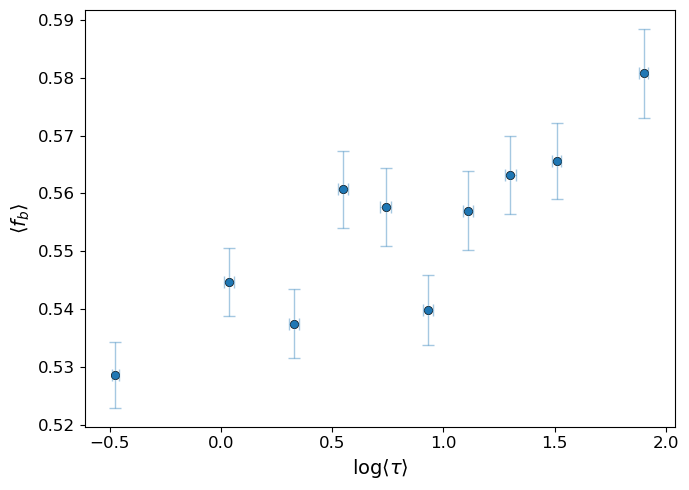

In [116]:
subconjuntos = np.array_split(df.sort_values(by='tau'), 10)
tau_mean = []
tau_benchmark_mean = []
bin_frac_mean = []
bin_frac_benchmark_mean = []

for i in range(len(subconjuntos)):
    tau_vals = subconjuntos[i]["tau"].values
    tau_errs = subconjuntos[i]["e_tau"].values
    tau_ufloats = unp.uarray(tau_vals, tau_errs)
    tau_mean.append(unp.log10(tau_ufloats).mean())

    # bin_frac y er_bin_frac
    bf_vals = subconjuntos[i]["bin_frac_corr"].values
    bf_errs = subconjuntos[i]["e_bin_frac"].values
    bf_ufloats = unp.uarray(bf_vals, bf_errs)
    bin_frac_mean.append((bf_ufloats).mean())

tau_mean = np.array(tau_mean)
bin_frac_mean = np.array(bin_frac_mean)


x = unp.nominal_values(tau_mean)
y = unp.nominal_values(bin_frac_mean)
xerr = unp.std_devs(tau_mean)
yerr = unp.std_devs(bin_frac_mean)

fig, ax = plt.subplots(figsize=(7, 5))

# Scatterplot para todos os dados
sns.scatterplot(x=x, y=y, ax=ax, color='tab:blue', edgecolor='k',)
ax.errorbar(x, y,xerr=xerr, yerr=yerr,fmt='none',ecolor='tab:blue',alpha=0.4,capsize=4,elinewidth=1,)

# Escala logarítmica no eixo x
#ax.set_xscale('log')

ax.set_xlabel(r"log$\langle \tau \rangle$", fontdict=font)
ax.set_ylabel(r"$\langle f_b \rangle$", fontdict=font)
ax.tick_params(axis='both', labelsize=labelsize)

plt.tight_layout()
plt.savefig('Figures/fb_tau.png', dpi=300)
plt.show()
